# Phần 1 — Deep Leakage from Gradients (DLG) & iDLG trên LeNet, kèm DP-SGD defense

**Pillar:** Security — privacy trong Federated Learning (FL).

**Claim under test:** *"In Federated Learning, raw data never leaves the device — only gradients are shared."*
Notebook này cho thấy chỉ từ **gradient của một client (batch size = 1)**, attacker có thể **reconstruct ground-truth image** của client đó.

**Contents:**
1. **DLG** (Zhu et al., NeurIPS 2019) — jointly optimize *dummy image* và *dummy label* sao cho gradient của chúng match với leaked gradient. Code lấy từ notebook Colab chính thức của tác giả.
2. **iDLG** (Zhao et al., 2020) — recover *ground-truth label* bằng closed-form từ gradient, sau đó chỉ optimize dummy image. Code bám theo repo của tác giả: https://github.com/PatrickZH/Improved-Deep-Leakage-from-Gradients
3. **DP-SGD defense** (Abadi et al., 2016) — clip L2 norm của gradient rồi cộng Gaussian noise *trước khi* chia sẻ, để đo mức protection mà nó mang lại.

**Model:** LeNet (4 khối Conv + Sigmoid, không MaxPool/BatchNorm). **Dataset:** CIFAR-10, mỗi lần một ảnh (batch size = 1) — cùng dataset với Part 2 (ResNet-50 + Inverting Gradients) để so sánh trực tiếp.

## 1. Imports, dataset CIFAR-10 và helper functions

- `torch.manual_seed(50)` để kết quả reproducible.
- `label_to_onehot`: đổi label (số nguyên) thành vector one-hot (10 class của CIFAR-10).
- `cross_entropy_for_onehot`: cross-entropy nhận **soft label** (phân phối xác suất) thay vì class index:
$$\mathcal{L}(z, y) = -\sum_{c} y_c \log \mathrm{softmax}(z)_c$$
  Cần dạng này vì DLG optimize *dummy label* dưới dạng phân phối liên tục (qua softmax), còn label thật chỉ là trường hợp one-hot.

In [1]:
%matplotlib inline

import numpy as np
from pprint import pprint

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
from torchvision import models, datasets, transforms
torch.manual_seed(50)

print(torch.__version__, torchvision.__version__)

2.10.0+cu128 0.25.0+cu128


In [2]:
dst = datasets.CIFAR10("./data")
tp = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor()
])
tt = transforms.ToPILImage()

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
print("Running on %s" % device)

def label_to_onehot(target, num_classes=10):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target

def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

Running on cuda


## 2. Victim model — LeNet với Sigmoid

$$f_\theta(x) = W_{fc}\,\sigma\big(\mathrm{Conv}_4(\sigma(\mathrm{Conv}_3(\sigma(\mathrm{Conv}_2(\sigma(\mathrm{Conv}_1(x)))))))\big) + b_{fc}$$

- DLG optimize **input image** thông qua *gradient của gradient* (xem mục 4), nên loss phải differentiable hai lần theo $x$.
  ReLU có second derivative bằng 0 hầu như mọi nơi, còn MaxPool/BatchNorm làm loss surface kém smooth hoặc phụ thuộc batch,
  nên đều làm yếu tín hiệu optimization của attacker. **Sigmoid** smooth ($C^\infty$) nên được chọn.
- `weights_init` khởi tạo weights và bias theo $\mathrm{Uniform}(-0.5, 0.5)$ — model gần trạng thái random init,
  tương ứng threat model: attacker eavesdrop ở **những round FL đầu tiên** (đúng theo bài báo).
- Lớp fully-connected cuối có 10 output (10 class của CIFAR-10).

In [3]:
def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
        )
        self.fc = nn.Sequential(
            nn.Linear(768, 10)
        )

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        # print(out.size())
        out = self.fc(out)
        return out

net = LeNet().to(device)

net.apply(weights_init)
criterion = cross_entropy_for_onehot

## 3. Mô phỏng một bước training của client FL

Client (honest participant) tính gradient cục bộ trên ảnh private $(x, y)$ rồi gửi cho server:

$$\Delta w = \nabla_\theta\,\mathcal{L}\big(f_\theta(x),\, y\big)$$

Attacker (honest-but-curious server hoặc eavesdropper) **chỉ quan sát $\Delta w$** (`original_dy_dx`), không thấy $(x, y)$.
Mục tiêu của attacker: reconstruct $x$ (và $y$) chỉ từ $\Delta w$.

GT label is 3. 
Onehot label is 3.


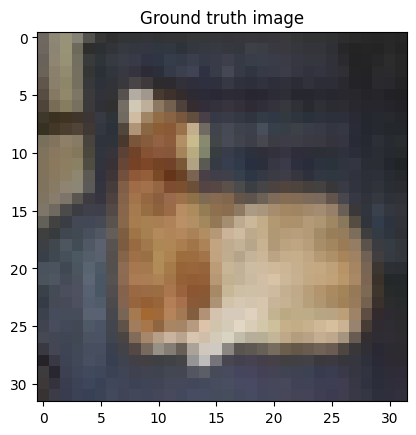

In [4]:
######### honest partipant #########
img_index = 17
gt_data = tp(dst[img_index][0]).to(device)
gt_data = gt_data.view(1, *gt_data.size())
gt_label = torch.Tensor([dst[img_index][1]]).long().to(device)
gt_label = gt_label.view(1, )
gt_onehot_label = label_to_onehot(gt_label, num_classes=10)

plt.imshow(tt(gt_data[0].cpu()))
plt.title("Ground truth image")
print("GT label is %d." % gt_label.item(), "\nOnehot label is %d." % torch.argmax(gt_onehot_label, dim=-1).item())

# compute original gradient
out = net(gt_data)
y = criterion(out, gt_onehot_label)
dy_dx = torch.autograd.grad(y, net.parameters())


# share the gradients with other clients
original_dy_dx = list((_.detach().clone() for _ in dy_dx))

## 4. DLG attack (Zhu et al., NeurIPS 2019)

Bắt đầu từ dummy image $x'$ và dummy label $y'$ (khởi tạo random noise bằng `torch.randn`), DLG tìm cặp $(x', y')$ sao cho gradient sinh ra match với leaked gradient:

$$x^{*}, y'^{*} \;=\; \arg\min_{x',\, y'} \; \Big\lVert\, \nabla_\theta\,\mathcal{L}\big(f_\theta(x'), y'\big) \;-\; \Delta w \,\Big\rVert_2^2$$

Ở bước khởi tạo dưới đây, `dummy_data` là ảnh noise và `dummy_label` là vector logit ngẫu nhiên (10 chiều).

Dummy label is 7.


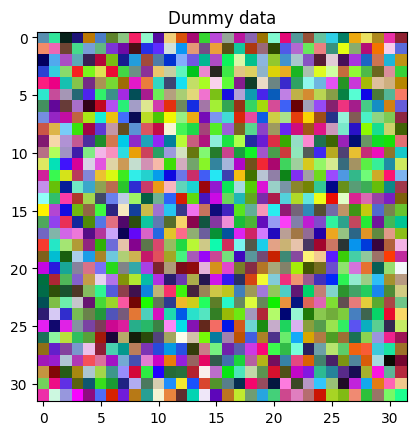

In [5]:
# generate dummy data and label
dummy_data = torch.randn(gt_data.size()).to(device).requires_grad_(True)
dummy_label = torch.randn(gt_onehot_label.size()).to(device).requires_grad_(True)

plt.imshow(tt(dummy_data[0].cpu()))
plt.title("Dummy data")
print("Dummy label is %d." % torch.argmax(dummy_label, dim=-1).item())

### Optimization loop của DLG

- Objective tự nó được xây từ một gradient của $\mathcal L$ (`torch.autograd.grad(..., create_graph=True)`), nên optimize theo $x'$ đòi hỏi
  backpropagate qua gradient đó thêm một lần nữa (**double backprop**).
- Dummy label được đưa qua `softmax` để thành soft label; `dummy_data` và `dummy_label` được optimize **đồng thời** bằng **L-BFGS**
  (`torch.optim.LBFGS`, default parameters, `lr = 1`), 300 iterations.
- `grad_diff` = tổng bình phương chênh lệch giữa dummy gradient và ground-truth gradient trên mọi parameter. Loss càng nhỏ, dummy image càng gần ground-truth image.

In [6]:
optimizer = torch.optim.LBFGS([dummy_data, dummy_label] )

history = []
for iters in range(300):
    def closure():
        optimizer.zero_grad()

        pred = net(dummy_data)
        dummy_onehot_label = F.softmax(dummy_label, dim=-1)
        dummy_loss = criterion(pred, dummy_onehot_label) # TODO: fix the gt_label to dummy_label in both code and slides.
        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = 0
        grad_count = 0
        for gx, gy in zip(dummy_dy_dx, original_dy_dx): # TODO: fix the variablas here
            grad_diff += ((gx - gy) ** 2).sum()
            grad_count += gx.nelement()
        # grad_diff = grad_diff / grad_count * 1000
        grad_diff.backward()

        return grad_diff

    optimizer.step(closure)
    if iters % 10 == 0:
        current_loss = closure()
        print(iters, "%.4f" % current_loss.item())
    history.append(tt(dummy_data[0].cpu()))

0 15.2180
10 0.2934
20 0.0338
30 0.0093
40 0.0041
50 0.0025
60 0.0018
70 0.0012
80 0.0009
90 0.0007
100 0.0006
110 0.0005
120 0.0004
130 0.0004
140 0.0003
150 0.0003
160 0.0002
170 0.0002
180 0.0002
190 0.0002
200 0.0002
210 0.0001
220 0.0001
230 0.0001
240 0.0001
250 0.0001
260 0.0001
270 0.0001
280 0.0001
290 0.0001


### Kết quả DLG

Mỗi ô là dummy image ở một mốc iteration (mỗi 10 iterations). Nếu attack thành công, ảnh sẽ dần chuyển từ noise sang ground-truth image ở mục 3.
Dòng in ra bên dưới là label mà DLG tìm được (`argmax` của `dummy_label`) — DLG optimize label cùng ảnh nên **không đảm bảo** đúng label thật.

Dummy label is 3.


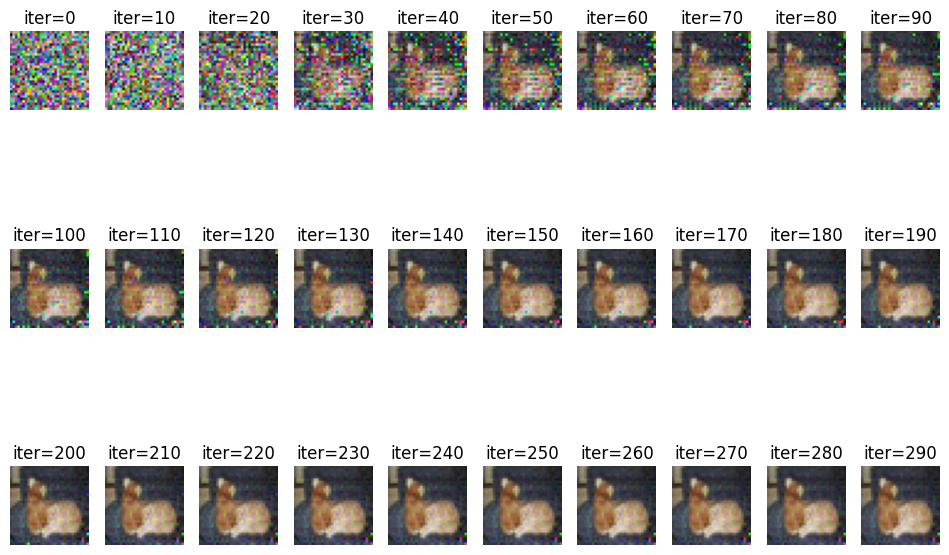

In [7]:
plt.figure(figsize=(12, 8))
for i in range(30):
  plt.subplot(3, 10, i + 1)
  plt.imshow(history[i * 10])
  plt.title("iter=%d" % (i * 10))
  plt.axis('off')
print("Dummy label is %d." % torch.argmax(dummy_label, dim=-1).item())

## 5. iDLG attack — closed-form label + chỉ optimize ảnh (Zhao et al., 2020)

Dùng lại cùng `net`, cùng ground-truth image và cùng leaked gradient `original_dy_dx` như DLG.

**Recover label trong một bước.** Với cross-entropy, gradient theo hàng $i$ của weight lớp cuối là

$$\frac{\partial \mathcal{L}}{\partial W_{i}} = \big(\mathrm{softmax}(z)_i - \mathbb{1}[i = y]\big)\, h^{\top}$$

trong đó $h$ là feature vector đầu vào của lớp cuối (output của Sigmoid nên $h_j > 0$). Do đó tổng theo các cột
$\sum_j \partial\mathcal{L}/\partial W_{ij}$ **chỉ âm ở đúng class thật** ($\mathrm{softmax}_i - 1 < 0$) và **dương ở mọi class còn lại** ($\mathrm{softmax}_i > 0$):

$$\hat{y} = \arg\min_i \sum_j \frac{\partial \mathcal{L}}{\partial W_{ij}}$$

Với batch size = 1, label được recover **chính xác** mà không cần optimize. Sau đó iDLG cố định label $\hat y$ và chỉ optimize ảnh:

$$x^{*} = \arg\min_{x'} \; \big\lVert \nabla_\theta\,\mathcal{L}(f_\theta(x'), \hat y) - \Delta w \big\rVert_2^2$$

So với DLG: bớt một biến cần optimize (`dummy_label`), nên thường converge nhanh và ổn định hơn. Loop dừng sớm khi `loss < 1e-6`.

iDLG label is 3. 
GT label is 3.


Text(0.5, 1.0, 'iDLG dummy data')

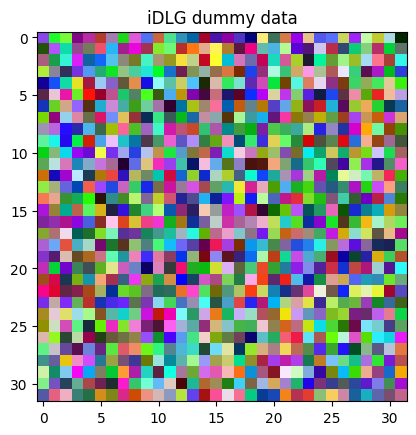

In [8]:
######### iDLG: recover the ground-truth label from the leaked gradient #########
# original_dy_dx[-2] is the gradient of fc.weight, shape [num_classes, 768]
label_pred = torch.argmin(torch.sum(original_dy_dx[-2], dim=-1), dim=-1).detach().reshape((1,)).requires_grad_(False)
print("iDLG label is %d." % label_pred.item(), "\nGT label is %d." % gt_label.item())

# generate dummy data (no dummy label anymore)
idlg_dummy_data = torch.randn(gt_data.size()).to(device).requires_grad_(True)

plt.imshow(tt(idlg_dummy_data[0].cpu()))
plt.title("iDLG dummy data")

In [9]:
idlg_criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.LBFGS([idlg_dummy_data], lr=1.0)

idlg_history = []
for iters in range(300):
    def closure():
        optimizer.zero_grad()

        pred = net(idlg_dummy_data)
        dummy_loss = idlg_criterion(pred, label_pred)
        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = 0
        for gx, gy in zip(dummy_dy_dx, original_dy_dx):
            grad_diff += ((gx - gy) ** 2).sum()
        grad_diff.backward()

        return grad_diff

    optimizer.step(closure)
    if iters % 10 == 0:
        current_loss = closure()
        print(iters, "%.8f" % current_loss.item())
        if current_loss.item() < 0.000001: # converge
            break
    idlg_history.append(tt(idlg_dummy_data[0].cpu()))

0 12.11884594
10 0.30083957
20 0.03281532
30 0.00965714
40 0.00436193
50 0.00239853
60 0.00157149
70 0.00111820
80 0.00083904
90 0.00074746
100 0.00055727
110 0.00046727
120 0.00040839
130 0.00034781
140 0.00030159
150 0.00026833
160 0.00024980
170 0.00022568
180 0.00020364
190 0.00018728
200 0.00017314
210 0.00016315
220 0.00015145
230 0.00013984
240 0.00013223
250 0.00012565
260 0.00011644
270 0.00010967
280 0.00010492
290 0.00009831


### Kết quả iDLG và so sánh với DLG

Ô đầu tiên là dummy image ở iteration 0, các ô sau cách nhau 10 iterations. Hai dòng in ra so sánh **label** (iDLG, DLG, ground truth) và **MSE** giữa ảnh reconstruct với ground-truth image
(MSE càng nhỏ, ảnh reconstruct càng giống ảnh gốc).

iDLG label is 3. | DLG label is 3. | GT label is 3.
MSE to ground truth -> DLG: 0.00144560 | iDLG: 0.00173435


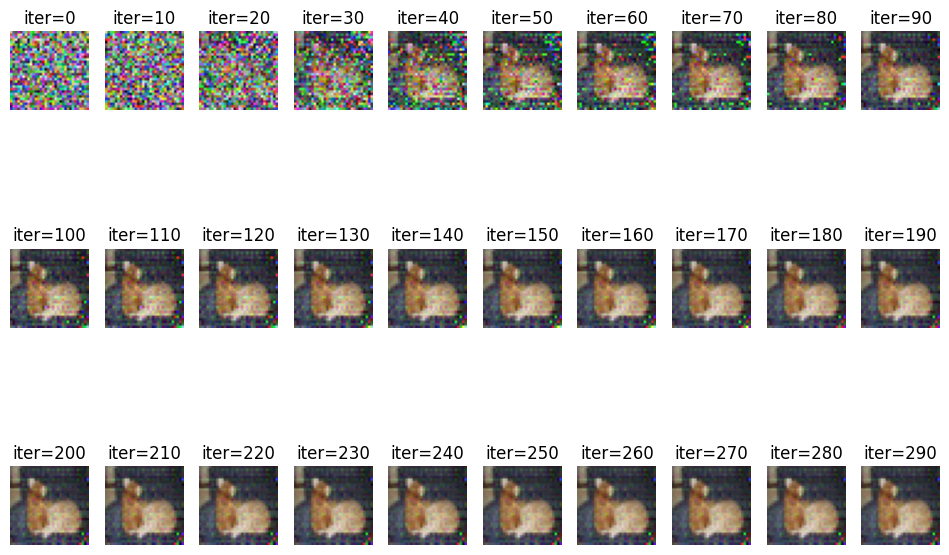

In [10]:
plt.figure(figsize=(12, 8))
for i in range(min(30, (len(idlg_history) + 9) // 10)):
  plt.subplot(3, 10, i + 1)
  plt.imshow(idlg_history[i * 10])
  plt.title("iter=%d" % (i * 10))
  plt.axis('off')
print("iDLG label is %d." % label_pred.item(), "| DLG label is %d." % torch.argmax(dummy_label, dim=-1).item(), "| GT label is %d." % gt_label.item())
print("MSE to ground truth -> DLG: %.8f | iDLG: %.8f" % (torch.mean((dummy_data - gt_data) ** 2).item(), torch.mean((idlg_dummy_data - gt_data) ** 2).item()))

## 6. DP-SGD defense — gradient clipping + Gaussian noise (Abadi et al., 2016)

Defense được áp dụng **ở phía client, trước khi gradient rời khỏi thiết bị**, nên attacker chỉ thấy phiên bản đã bị biến đổi $\tilde g$.
Đầu tiên clip L2 norm toàn cục của gradient về ngưỡng $C$ (clipping threshold):

$$\mathrm{clip}(g, C) = g \cdot \min\!\left(1,\; \frac{C}{\lVert g \rVert_2}\right)$$

rồi cộng Gaussian noise với noise multiplier $\sigma$:

$$\tilde{g} = \mathrm{clip}(g, C) + \mathcal{N}\!\left(0,\; (\sigma C)^2 I\right)$$

$C$ càng lớn thì càng ít bị clip (giữ nhiều signal hơn); $\sigma$ càng lớn thì noise càng mạnh. Ta sweep lưới $(C, \sigma)$ và đo mức suy giảm chất lượng reconstruction.

- Attacker dùng **iDLG** làm attack tham chiếu (nhanh và ổn định hơn DLG), recover label **từ gradient đã bị defense**.
- Metrics: **MSE** giữa ảnh reconstruct và ground-truth image, và **PSNR** $= 10\log_{10}(1/\mathrm{MSE})$ (data range $R=1$; PSNR càng cao thì ảnh reconstruct càng giống ảnh gốc).
- Để chạy nhanh, lưới chỉ có **2 giá trị $C$ × 4 giá trị $\sigma$ = 8 cấu hình**, mỗi cấu hình chạy `NUM_ITERS_DEFENSE = 50` iterations L-BFGS (ít hơn 300 ở mục 4–5). Nếu muốn kết quả chi tiết hơn, tăng `NUM_ITERS_DEFENSE` hoặc mở rộng `clip_norms` / `noise_stds`.
- Các giá trị $C$ được chọn theo **global L2 norm** của gradient gốc (in ra ở đầu output): $C$ lớn hơn norm thì gradient không bị clip, còn $C$ nhỏ hơn nhiều (ví dụ $C = 0.5$ khi norm ≈ 28) thu nhỏ gradient quá mạnh khiến attacker không match được và optimization diverge.

In [11]:
import pandas as pd

# Lưới nhỏ (2 x 4 = 8 cấu hình) và ít iterations để chạy nhanh. C được chọn theo global L2 norm của gradient (in ra bên dưới):
# C > norm -> không bị clip, C < norm -> gradient bị thu nhỏ. Noise thực tế trên mỗi phần tử là sigma * C.
clip_norms = [10.0, 30.0]
noise_stds = [0.0, 0.0001, 0.001, 0.01]
NUM_ITERS_DEFENSE = 50

total_norm = torch.sqrt(sum((g ** 2).sum() for g in original_dy_dx))
print("Global L2 norm of the original gradient: %.4f" % total_norm.item())

defense_results = []
for C in clip_norms:
    for sigma in noise_stds:
        # ---- client side: clip the global L2 norm, then add Gaussian noise N(0, (sigma * C)^2) to every tensor ----
        clip_coef = torch.clamp(C / (total_norm + 1e-6), max=1.0)
        defended_dy_dx = [g * clip_coef + torch.randn_like(g) * sigma * C for g in original_dy_dx]

        # ---- attacker side: iDLG on the defended gradient ----
        def_label_pred = torch.argmin(torch.sum(defended_dy_dx[-2], dim=-1), dim=-1).detach().reshape((1,)).requires_grad_(False)
        def_dummy_data = torch.randn(gt_data.size()).to(device).requires_grad_(True)
        optimizer = torch.optim.LBFGS([def_dummy_data], lr=1.0)

        for iters in range(NUM_ITERS_DEFENSE):
            def closure():
                optimizer.zero_grad()

                pred = net(def_dummy_data)
                dummy_loss = idlg_criterion(pred, def_label_pred)
                dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

                grad_diff = 0
                for gx, gy in zip(dummy_dy_dx, defended_dy_dx):
                    grad_diff += ((gx - gy) ** 2).sum()
                grad_diff.backward()

                return grad_diff

            optimizer.step(closure)

        mse = torch.mean((def_dummy_data.detach() - gt_data) ** 2).item()
        defense_results.append({
            "clip_norm": C, "noise_std": sigma,
            "mse": mse, "psnr": -10 * np.log10(mse),
            "label_correct": def_label_pred.item() == gt_label.item(),
            "image": def_dummy_data.detach().cpu(),
        })
        print("[%2d/%d] C=%s, sigma=%s -> MSE %.6f, PSNR %.2f dB, label %s" % (
            len(defense_results), len(clip_norms) * len(noise_stds), C, sigma,
            mse, defense_results[-1]["psnr"], "correct" if defense_results[-1]["label_correct"] else "WRONG"))

defense_df = pd.DataFrame(defense_results)
defense_df.drop(columns="image")

Global L2 norm of the original gradient: 29.4434
[ 1/8] C=10.0, sigma=0.0 -> MSE 2.044863, PSNR -3.11 dB, label correct
[ 2/8] C=10.0, sigma=0.0001 -> MSE 17.396406, PSNR -12.40 dB, label correct
[ 3/8] C=10.0, sigma=0.001 -> MSE 24.323439, PSNR -13.86 dB, label correct
[ 4/8] C=10.0, sigma=0.01 -> MSE 489.463135, PSNR -26.90 dB, label correct
[ 5/8] C=30.0, sigma=0.0 -> MSE 0.024017, PSNR 16.19 dB, label correct
[ 6/8] C=30.0, sigma=0.0001 -> MSE 0.038442, PSNR 14.15 dB, label correct
[ 7/8] C=30.0, sigma=0.001 -> MSE 6.693157, PSNR -8.26 dB, label correct
[ 8/8] C=30.0, sigma=0.01 -> MSE 83.500427, PSNR -19.22 dB, label correct


,clip_norm,noise_std,mse,psnr,label_correct
0,10.0,0.0000,2.044863,-3.106642,True
1,10.0,0.0001,17.396406,-12.404595,True
2,10.0,0.0010,24.323439,-13.860250,True
3,10.0,0.0100,489.463135,-26.897200,True
4,30.0,0.0000,0.024017,16.194792,True
5,30.0,0.0001,0.038442,14.151991,True
6,30.0,0.0010,6.693157,-8.256310,True
7,30.0,0.0100,83.500427,-19.216887,True


### Chất lượng reconstruction theo noise level

Trục hoành là noise multiplier $\sigma$ (thang `symlog` để hiển thị được cả $\sigma = 0$), mỗi đường ứng với một clipping threshold $C$.
**PSNR giảm** (hoặc **MSE tăng**) khi $\sigma$ tăng nghĩa là defense hiệu quả hơn.

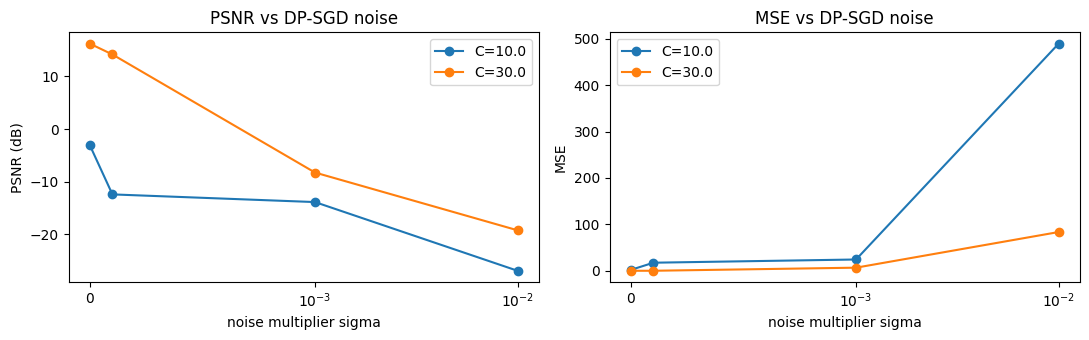

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for C, group in defense_df.groupby("clip_norm"):
    axes[0].plot(group["noise_std"], group["psnr"], marker="o", label="C=%s" % C)
    axes[1].plot(group["noise_std"], group["mse"], marker="o", label="C=%s" % C)
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR vs DP-SGD noise")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs DP-SGD noise")
for ax in axes:
    ax.set_xscale("symlog", linthresh=1e-3)
    ax.set_xlabel("noise multiplier sigma")
    ax.legend()
plt.tight_layout()
plt.show()

### Ảnh reconstruct theo noise level (cố định clipping threshold $C$)

Ô đầu là ground-truth image, các ô sau là ảnh iDLG reconstruct với $\sigma$ tăng dần. Mục đích là xem bằng mắt tại noise level nào ảnh không còn nhận ra được.

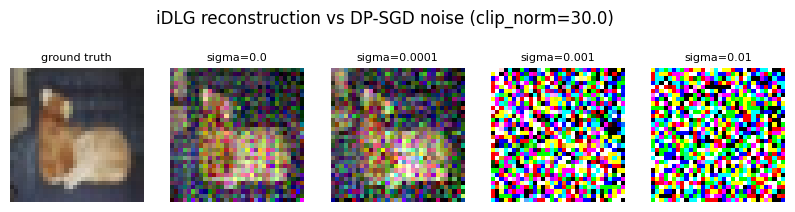

In [13]:
C_fixed = 30.0
chosen = [r for r in defense_results if r["clip_norm"] == C_fixed]

plt.figure(figsize=(2 * (len(chosen) + 1), 2.6))
plt.subplot(1, len(chosen) + 1, 1)
plt.imshow(tt(gt_data[0].cpu()))
plt.title("ground truth", fontsize=8)
plt.axis('off')
for k, r in enumerate(chosen):
    plt.subplot(1, len(chosen) + 1, k + 2)
    plt.imshow(tt(r["image"][0].clamp(0, 1)))
    plt.title("sigma=%s" % r["noise_std"], fontsize=8)
    plt.axis('off')
plt.suptitle("iDLG reconstruction vs DP-SGD noise (clip_norm=%s)" % C_fixed)
plt.show()